In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df1 = pd.read_csv("index_1.csv")
df2 = pd.read_csv("index_2.csv")

In [4]:
df1.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [6]:
df1.shape

(3636, 6)

In [7]:
df2.shape

(262, 5)

In [9]:
df1.describe(include='all')

,date,datetime,cash_type,card,money,coffee_name
count,3636,3636,3636,3547,3636.000000,3636
unique,381,3636,2,1316,NaN,8
top,2024-10-11,2024-03-01 10:15:50.520,card,ANON-0000-0000-0012,NaN,Americano with Milk
freq,26,1,3547,129,NaN,824
mean,NaN,NaN,NaN,NaN,31.746859,NaN
std,NaN,NaN,NaN,NaN,4.919926,NaN
min,NaN,NaN,NaN,NaN,18.120000,NaN
25%,NaN,NaN,NaN,NaN,27.920000,NaN
50%,NaN,NaN,NaN,NaN,32.820000,NaN
75%,NaN,NaN,NaN,NaN,35.760000,NaN


In [13]:
df1.isnull().sum()/len(df1)*100

date           0.000000
datetime       0.000000
cash_type      0.000000
card           2.447745
money          0.000000
coffee_name    0.000000
dtype: float64

In [28]:
df1.columns
df1.dtypes

date                datetime64[ns]
transaction_date    datetime64[ns]
payment_type                object
card                        object
amount                     float64
item_name                   object
dtype: object

In [21]:
df1['date'] = pd.to_datetime(df1['date']).dt.normalize()

In [31]:
df1.rename(columns={'datetime':'transaction_date','cash_type':'payment_type','card':'customer_id','money':'amount','coffee_name':'item_name'},inplace=True)

In [32]:
df1.columns

Index(['date', 'transaction_date', 'payment_type', 'customer_id', 'amount',
       'item_name'],
      dtype='object')

In [27]:
df1['transaction_date'] = pd.to_datetime(df1['transaction_date'])

In [46]:
for col in ['payment_type','item_name']:
    print(  df1[col].nunique())
    print( df1[col].unique())
    

2
['card' 'cash']
8
['Latte' 'Hot Chocolate' 'Americano' 'Americano with Milk' 'Cocoa'
 'Cortado' 'Espresso' 'Cappuccino']


In [34]:
df1['source_file'] = 'index_1'

In [29]:
df2.describe(include='all')

,date,datetime,cash_type,money,coffee_name
count,262,262,262,262.00000,262
unique,41,254,2,NaN,30
top,2025-02-26,2025-02-09 18:01:22,card,NaN,Americano with milk
freq,17,3,182,NaN,44
mean,NaN,NaN,NaN,26.29771,NaN
std,NaN,NaN,NaN,4.25021,NaN
min,NaN,NaN,NaN,15.00000,NaN
25%,NaN,NaN,NaN,25.00000,NaN
50%,NaN,NaN,NaN,27.00000,NaN
75%,NaN,NaN,NaN,29.00000,NaN


In [30]:
df2['date'] = pd.to_datetime(df2['date']).dt.date

In [33]:
df2.rename(columns={'datetime':'transaction_date','cash_type':'payment_type','money':'amount','coffee_name':'item_name'},inplace=True)

In [35]:
df2['customer_id'] = pd.Series([pd.NA]*len(df2), dtype="string")

In [54]:
df2['source_file'] = 'index_2'

In [51]:
cols = ['date','transaction_date','customer_id','payment_type','amount','item_name', 'source_file']

In [49]:
df1.columns

Index(['date', 'transaction_date', 'payment_type', 'customer_id', 'amount',
       'item_name', 'source_file'],
      dtype='object')

df2.columns

In [53]:
df2.columns

Index(['date', 'transaction_date', 'payment_type', 'amount', 'item_name',
       'customer_id'],
      dtype='object')

In [55]:
merg = pd.concat([df1[cols],df2[cols]], ignore_index=True)

In [56]:
merg.head()

,date,transaction_date,customer_id,payment_type,amount,item_name,source_file
0,2024-03-01 00:00:00,2024-03-01 10:15:50.520000,ANON-0000-0000-0001,card,38.7,Latte,index_1
1,2024-03-01 00:00:00,2024-03-01 12:19:22.539000,ANON-0000-0000-0002,card,38.7,Hot Chocolate,index_1
2,2024-03-01 00:00:00,2024-03-01 12:20:18.089000,ANON-0000-0000-0002,card,38.7,Hot Chocolate,index_1
3,2024-03-01 00:00:00,2024-03-01 13:46:33.006000,ANON-0000-0000-0003,card,28.9,Americano,index_1
4,2024-03-01 00:00:00,2024-03-01 13:48:14.626000,ANON-0000-0000-0004,card,38.7,Latte,index_1


In [119]:
merg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3898 entries, 0 to 3897
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              3898 non-null   object 
 1   transaction_date  3898 non-null   object 
 2   customer_id       3547 non-null   object 
 3   payment_type      3898 non-null   object 
 4   amount            3898 non-null   float64
 5   item_name         3898 non-null   object 
 6   source_file       3898 non-null   object 
dtypes: float64(1), object(6)
memory usage: 213.3+ KB


In [57]:
merg.shape

(3898, 7)

In [121]:
merg['transaction_date'] = pd.to_datetime(merg['transaction_date'])

In [123]:
merg['month'] = merg['transaction_date'].dt.month
merg['month_name'] = merg['transaction_date'].dt.month_name()

In [78]:
g = merg.groupby('payment_type').sum('amount')
g['per'] =merg.groupby('payment_type').sum('amount')/ (merg['amount'].sum())*100
g.reset_index()

,payment_type,amount,per
0,card,117114.58,95.743188
1,cash,5207.00,4.256812


,amount
payment_type,
card,11711458.0
cash,520700.0


In [75]:
counts = merg['payment_type'].value_counts()
perc   = merg['payment_type'].value_counts(normalize=True) * 100
g_cnt = pd.DataFrame({'count': counts, 'per': perc}).reset_index(names='payment_type')

In [76]:
g_cnt


,payment_type,count,per
0,card,3729,95.664443
1,cash,169,4.335557


In [88]:
item= merg.groupby('item_name').sum('amount')
item.reset_index('item_name')

,item_name,amount
0,Americano,15437.26
1,Americano with Milk,25269.12
2,Americano with milk,1100.00
3,Cappuccino,18514.14
4,Caramel,22.00
5,Caramel coffee,56.00
6,Caramel with Irish whiskey,224.00
7,Caramel with chocolate,112.00
8,Caramel with milk,75.00
9,Chocolate,25.00


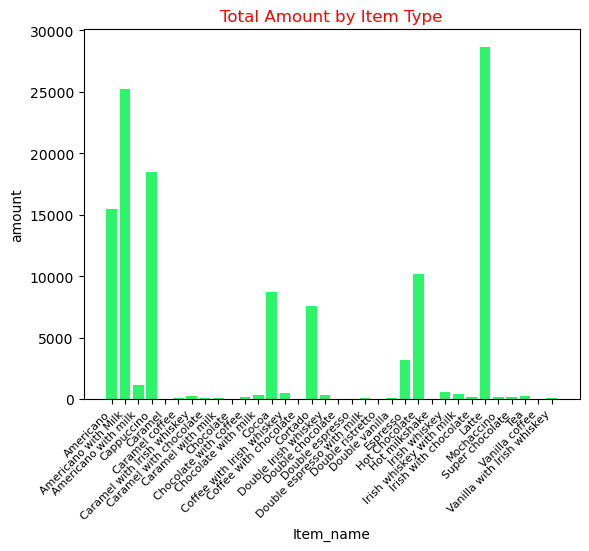

In [113]:
plt.bar(item.index, item.amount,color="#2CF569")
plt.title('Total Amount by Item Type', color='red')
plt.xlabel('Item_name')
plt.ylabel('amount')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.show()

In [107]:
pyt = merg.groupby('payment_type').sum('amount')
pyt.reset_index('payment_type')

,payment_type,amount
0,card,117114.58
1,cash,5207.00


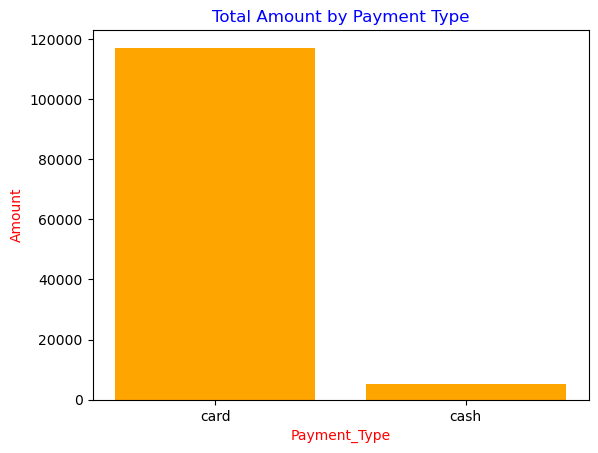

In [112]:
plt.bar(pyt.index, pyt.amount, color='#FFA500')
plt.title('Total Amount by Payment Type', color='blue')
plt.xlabel('Payment_Type',color='red')
plt.ylabel('Amount', color='red')
plt.show()



In [124]:
month = merg.groupby('month_name').sum('amount')
month.reset_index('month_name')                            

,month_name,amount,month
0,April,6720.56,784
1,August,7613.84,2176
2,December,8237.74,3108
3,February,16804.48,1122
4,January,6398.86,201
5,July,6915.94,1659
6,June,7758.76,1362
7,March,20337.64,1947
8,May,9063.42,1335
9,November,8590.54,2849


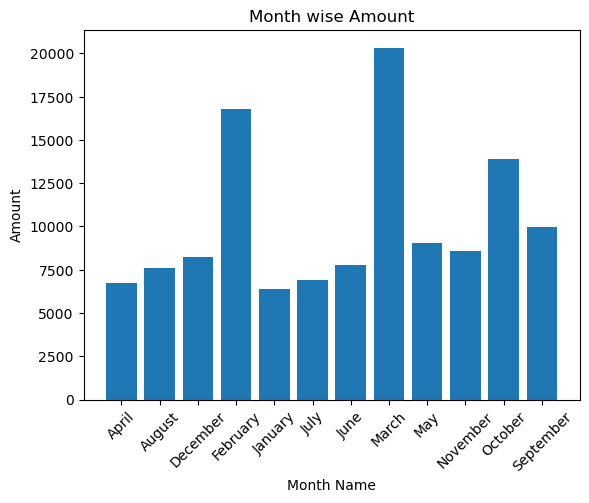

In [127]:
plt.bar(month.index, month.amount)
plt.title('Month wise Amount')
plt.xlabel("Month Name")
plt.ylabel('Amount')
plt. xticks(rotation=45)
plt.show()